In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

input_img = cv2.imread("DINGO3_Frame0.jpg")
background_img = cv2.imread("DINGO3_Background.jpg")

gray_input = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
gray_background = cv2.cvtColor(background_img, cv2.COLOR_BGR2GRAY)

In [2]:
diff_img = cv2.absdiff(gray_input, gray_background)

threshold_value = 40
_, binary_mask = cv2.threshold(
diff_img,
threshold_value,
255,
cv2.THRESH_BINARY
)

#Image pixels are compared to threshold, all those that exceed are set to 255



In [3]:
kernel = cv2.getStructuringElement(
cv2.MORPH_ELLIPSE,
(5, 5)
)

dilated = cv2.dilate(binary_mask, kernel)
eroded = cv2.erode(dilated, kernel)


In [4]:
clean_mask = cv2.morphologyEx(
binary_mask,
cv2.MORPH_CLOSE,
kernel
)

#take our binary mask, and combine dilution & erosion to remove noise; a closing is a dilation followed by an erosion

In [5]:
mask_3ch = cv2.cvtColor(clean_mask, cv2.COLOR_GRAY2BGR) / 255.0
cut_out_img = (input_img * mask_3ch).astype(np.uint8)

In [6]:
def compute_background_subtracted_img(input_img, background_img):
    # Convert to gray
    gray_input = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    gray_background = cv2.cvtColor(background_img, cv2.COLOR_BGR2GRAY)
    # Compute difference
    diff_img = cv2.absdiff(gray_input, gray_background)
    # Normalisation
    diff_img = cv2.normalize(diff_img, None, 0, 255,
    cv2.NORM_MINMAX).astype(np.uint8)
    # Thresholding
    _, binary_mask = cv2.threshold(diff_img, 40, 255,
    cv2.THRESH_BINARY)
    # Create structuring element
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    # Perform dilation and erosion
    clean_mask = cv2.morphologyEx(
    binary_mask,
    cv2.MORPH_CLOSE,
    kernel
    )
    # Apply the binary mask
    mask_3ch = cv2.cvtColor(clean_mask,
    cv2.COLOR_GRAY2BGR) / 255.0
    cut_out_img = (input_img * mask_3ch).astype(np.uint8)
    return clean_mask, cut_out_img

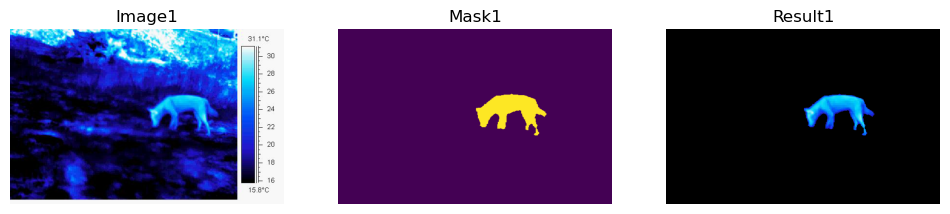

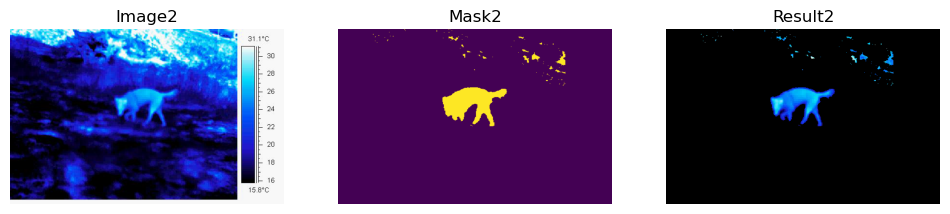

In [8]:
background_img = cv2.imread("DINGO3_Background.jpg")
dingo_img1 = cv2.imread("DINGO3_Frame0.jpg")
dingo_img2 = cv2.imread("DINGO3_Frame477.jpg")
dingo_images = [dingo_img1, dingo_img2]
for i, img in enumerate(dingo_images):
    mask, result = compute_background_subtracted_img(
        img,
        background_img
        )
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Image{i+1}")
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(mask)
    plt.title(f"Mask{i+1}")
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(result)
    plt.title(f"Result{i+1}")
    plt.axis('off')